# Cooling Mode Scenario Simulation

**Purpose:** Simulate a realistic summer day (06:00 → 18:00) to understand when the
heat pump activates for cooling under different outdoor / PV conditions, and how
the house reacts to open-window disturbances.

## Scenario Baseline
| Parameter | 06:00 | 12:00 (peak) |
|---|---|---|
| Indoor | 22.6 °C | — (model predicts) |
| Outdoor | 15 °C | 25 °C |
| PV | 0 W | 8 000 W |
| Cooling target | 23.0 °C | |

## Config Reference — Outlet Ranges
| Parameter | Value | Meaning |
|---|---|---|
| `COOLING_CLAMP_MIN_ABS` | 18.0 °C | HP shutdown point |
| `COOLING_CLAMP_MAX_ABS` | 24.0 °C | Upper cooling limit |
| `MIN_COOLING_DELTA_K` | 2.0 K | Min (inlet − outlet) gap for HP operation |
| `COOLING_SHUTDOWN_MARGIN_K` | 1.0 K | Effective floor = 19.0 °C |
| `PRE_COOL_LEAD_TIME_HOURS` | 8.0 h | Start cooling this far ahead |
| `PRE_COOL_TRIGGER_MARGIN_K` | 0.5 K | Trigger when peak > target + 0.5 |
| `PRE_COOL_MIN_PV_FORECAST_W` | 1 000 W | Guard: skip if PV too low |
| `PRE_COOL_MIN_OUTDOOR_FORECAST_C` | 22.0 °C | Guard: skip if outdoor too cool |

## Two Prediction Modes
1. **Trajectory mode** (`OverheatingPredictor`) — physics simulation: HP OFF trajectory + peak analysis
2. **Model mode** (`ThermalEquilibriumModel.calculate_optimal_outlet_temperature`) — equilibrium outlet calc + binary search

## 1 — Setup & Imports

In [1]:
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Resolve project root
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, os.path.join(ROOT, 'src'))
    sys.path.insert(0, ROOT)

# Suppress HA connection warnings during offline simulation
warnings.filterwarnings('ignore', category=UserWarning, module='ha_client')

from src.thermal_equilibrium_model import ThermalEquilibriumModel
from src.overheating_predictor import OverheatingPredictor
from src import config

print(f"Project root: {ROOT}")
print(f"Cooling outlet range: [{config.COOLING_CLAMP_MIN_ABS}, {config.COOLING_CLAMP_MAX_ABS}] °C")
print(f"Pre-cool lead time : {config.PRE_COOL_LEAD_TIME_HOURS} h")
print(f"Trigger margin     : {config.PRE_COOL_TRIGGER_MARGIN_K} K")
print(f"Min PV guard       : {config.PRE_COOL_MIN_PV_FORECAST_W} W")
print(f"Min outdoor guard  : {config.PRE_COOL_MIN_OUTDOOR_FORECAST_C} °C")

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Cooling outlet range: [18.0, 24.0] °C
Pre-cool lead time : 8.0 h
Trigger margin     : 0.5 K
Min PV guard       : 1000.0 W
Min outdoor guard  : 22.0 °C


## 2 — Thermal Model from Cooling State

In [2]:
# Load cooling-mode calibrated parameters
state_file = os.path.join(ROOT, 'Logs', 'unified_thermal_state_cooling.json')
with open(state_file) as f:
    cooling_state = json.load(f)

bp = cooling_state['baseline_parameters']
print("=== Cooling Thermal Parameters ===")
for k, v in bp.items():
    if isinstance(v, (int, float)):
        print(f"  {k:35s} = {v}")

# Build model with cooling parameters
model = ThermalEquilibriumModel()
model.thermal_time_constant = bp['thermal_time_constant']
model.heat_loss_coefficient = bp['heat_loss_coefficient']
model.outlet_effectiveness = bp['outlet_effectiveness']
model.slab_time_constant_hours = bp['slab_time_constant_hours']
model.external_source_weights['pv'] = bp['pv_heat_weight']
model.external_source_weights['fireplace'] = bp['fireplace_heat_weight']
model.external_source_weights['tv'] = bp['tv_heat_weight']
model.delta_t_floor = bp.get('delta_t_floor', 2.0)
model.solar_lag_minutes = bp.get('solar_lag_minutes', 45.0)

print(f"\nτ_thermal = {model.thermal_time_constant} h")
print(f"τ_slab    = {model.slab_time_constant_hours} h")
print(f"OE        = {model.outlet_effectiveness}")
print(f"HLC       = {model.heat_loss_coefficient}")
print(f"PV weight = {model.external_source_weights['pv']}")

=== Cooling Thermal Parameters ===
  thermal_time_constant               = 3.0
  equilibrium_ratio                   = 0.2
  total_conductance                   = 0.6
  heat_loss_coefficient               = 0.12
  outlet_effectiveness                = 0.9
  solar_lag_minutes                   = 45.0
  slab_time_constant_hours            = 0.8
  pv_heat_weight                      = 0.0003
  fireplace_heat_weight               = 1.0
  tv_heat_weight                      = 0.35
  delta_t_floor                       = 2.0
  fp_decay_time_constant              = 2.0
  room_spread_delay_minutes           = 30.0
  calibration_cycles                  = 0

τ_thermal = 3.0 h
τ_slab    = 0.8 h
OE        = 0.9
HLC       = 0.12
PV weight = 0.0003


## 3 — Helper: Build Forecast Arrays

Generate sinusoidal outdoor temperature and bell-curve PV profiles
from 06:00 → 18:00 (12 h horizon).

In [3]:
def build_forecasts(t_out_6am, t_out_peak, pv_peak, horizon_hours=12):
    """
    Build hourly forecast arrays for outdoor temp and PV.
    
    Outdoor: sinusoidal ramp from t_out_6am at 06:00 to t_out_peak at 14:00,
             then decline to t_out_peak - 3 by 18:00.
    PV: Gaussian bell curve peaking at 12:00 (6h into simulation).
    """
    hours = np.arange(horizon_hours + 1)  # 0..12 (06:00..18:00)
    
    # Outdoor: peak at hour 8 (= 14:00), smooth ramp
    peak_hour = 8  # 14:00
    t_out = np.where(
        hours <= peak_hour,
        t_out_6am + (t_out_peak - t_out_6am) * np.sin(np.pi / 2 * hours / peak_hour),
        t_out_peak - 3.0 * np.sin(np.pi / 2 * (hours - peak_hour) / (horizon_hours - peak_hour))
    )
    
    # PV: bell curve, peak at hour 6 (= 12:00 noon)
    pv_center = 6  # noon
    pv_sigma = 3.0  # width ≈ 6h usable window
    pv = pv_peak * np.exp(-0.5 * ((hours - pv_center) / pv_sigma) ** 2)
    pv = np.maximum(pv, 0)
    
    return t_out.tolist(), pv.tolist()


def build_features(t_out_forecast, pv_forecast, indoor_temp, inlet_temp=24.0):
    """Build a features dict compatible with OverheatingPredictor."""
    features = {
        'indoor_temp': indoor_temp,
        'outdoor_temp': t_out_forecast[0],
        'inlet_temp': inlet_temp,
        'pv_now': pv_forecast[0],
        'fireplace_on': 0,
        'tv_on': 0,
        'indoor_temp_delta_60m': 0.0,
    }
    for h in range(1, len(t_out_forecast)):
        features[f'temp_forecast_{h}h'] = t_out_forecast[h]
    for h in range(1, len(pv_forecast)):
        features[f'pv_forecast_{h}h'] = pv_forecast[h]
    return features


# Verify with baseline scenario
t_out, pv = build_forecasts(15.0, 25.0, 8000)
print("Hour | Outdoor °C | PV W")
print("-" * 35)
for h in range(len(t_out)):
    real_hour = 6 + h
    print(f" {real_hour:02d}:00 | {t_out[h]:8.1f}   | {pv[h]:7.0f}")

Hour | Outdoor °C | PV W
-----------------------------------
 06:00 |     15.0   |    1083
 07:00 |     17.0   |    1995
 08:00 |     18.8   |    3289
 09:00 |     20.6   |    4852
 10:00 |     22.1   |    6406
 11:00 |     23.3   |    7568
 12:00 |     24.2   |    8000
 13:00 |     24.8   |    7568
 14:00 |     25.0   |    6406
 15:00 |     23.9   |    4852
 16:00 |     22.9   |    3289
 17:00 |     22.2   |    1995
 18:00 |     22.0   |    1083


## 4 — Trajectory Mode: Passive Simulation (HP OFF)

The `OverheatingPredictor` runs the thermal model with **HP OFF**
(outlet = inlet) to see when indoor temperature exceeds the cooling target.
This is the core pre-cooling decision engine.

In [4]:
predictor = OverheatingPredictor()
COOLING_TARGET = 23.0  # °C
INDOOR_START = 22.6    # °C at 06:00
INLET_TEMP = 24.0      # °C (typical cooling inlet from NIBE)

# === Scenario Matrix ===
scenarios = {
    'A: Baseline (25°C / 8kW)':     {'t_peak': 25.0, 'pv_peak': 8000},
    'B: Hot day (30°C / 8kW)':      {'t_peak': 30.0, 'pv_peak': 8000},
    'C: Mild day (22°C / 5kW)':     {'t_peak': 22.0, 'pv_peak': 5000},
    'D: Extreme (33°C / 10kW)':     {'t_peak': 33.0, 'pv_peak': 10000},
    'E: Cloudy hot (28°C / 2kW)':   {'t_peak': 28.0, 'pv_peak': 2000},
    'F: Cool but sunny (20°C/9kW)': {'t_peak': 20.0, 'pv_peak': 9000},
}

results = {}
for name, params in scenarios.items():
    t_out, pv = build_forecasts(15.0, params['t_peak'], params['pv_peak'])
    features = build_features(t_out, pv, INDOOR_START, INLET_TEMP)
    
    result = predictor.predict_overheating_risk(
        current_indoor=INDOOR_START,
        target_cooling=COOLING_TARGET,
        features=features,
        thermal_model=model,
        climate_mode='cooling',
    )
    results[name] = result
    
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Risk:           {result['risk']}")
    print(f"  Should cool:    {result['should_cool_now']}")
    print(f"  Peak temp:      {result['peak_temp']:.2f} °C")
    print(f"  Peak hour:      {result['peak_hour']:.1f} h  (= {6 + result['peak_hour']:.0f}:00)")
    print(f"  Trigger thresh: {result.get('trigger_threshold', COOLING_TARGET + 0.5):.1f} °C")
    print(f"  Reason:         {result['reason']}")


  A: Baseline (25°C / 8kW)
  Risk:           True
  Should cool:    False
  Peak temp:      28.55 °C
  Peak hour:      12.0 h  (= 18:00)
  Trigger thresh: 23.5 °C
  Reason:         predicted peak 28.6°C in 12.0h (> 23.5°C, but 12.0h > 8h lead — waiting)

  B: Hot day (30°C / 8kW)
  Risk:           True
  Should cool:    False
  Peak temp:      28.01 °C
  Peak hour:      12.0 h  (= 18:00)
  Trigger thresh: 23.5 °C
  Reason:         predicted peak 28.0°C in 12.0h (> 23.5°C, but 12.0h > 8h lead — waiting)

  C: Mild day (22°C / 5kW)
  Risk:           True
  Should cool:    False
  Peak temp:      27.92 °C
  Peak hour:      12.0 h  (= 18:00)
  Trigger thresh: 23.5 °C
  Reason:         predicted peak 27.9°C in 12.0h (> 23.5°C, but 12.0h > 8h lead — waiting)

  D: Extreme (33°C / 10kW)
  Risk:           True
  Should cool:    False
  Peak temp:      29.45 °C
  Peak hour:      12.0 h  (= 18:00)
  Trigger thresh: 23.5 °C
  Reason:         predicted peak 29.5°C in 12.0h (> 23.5°C, but 12.0h > 

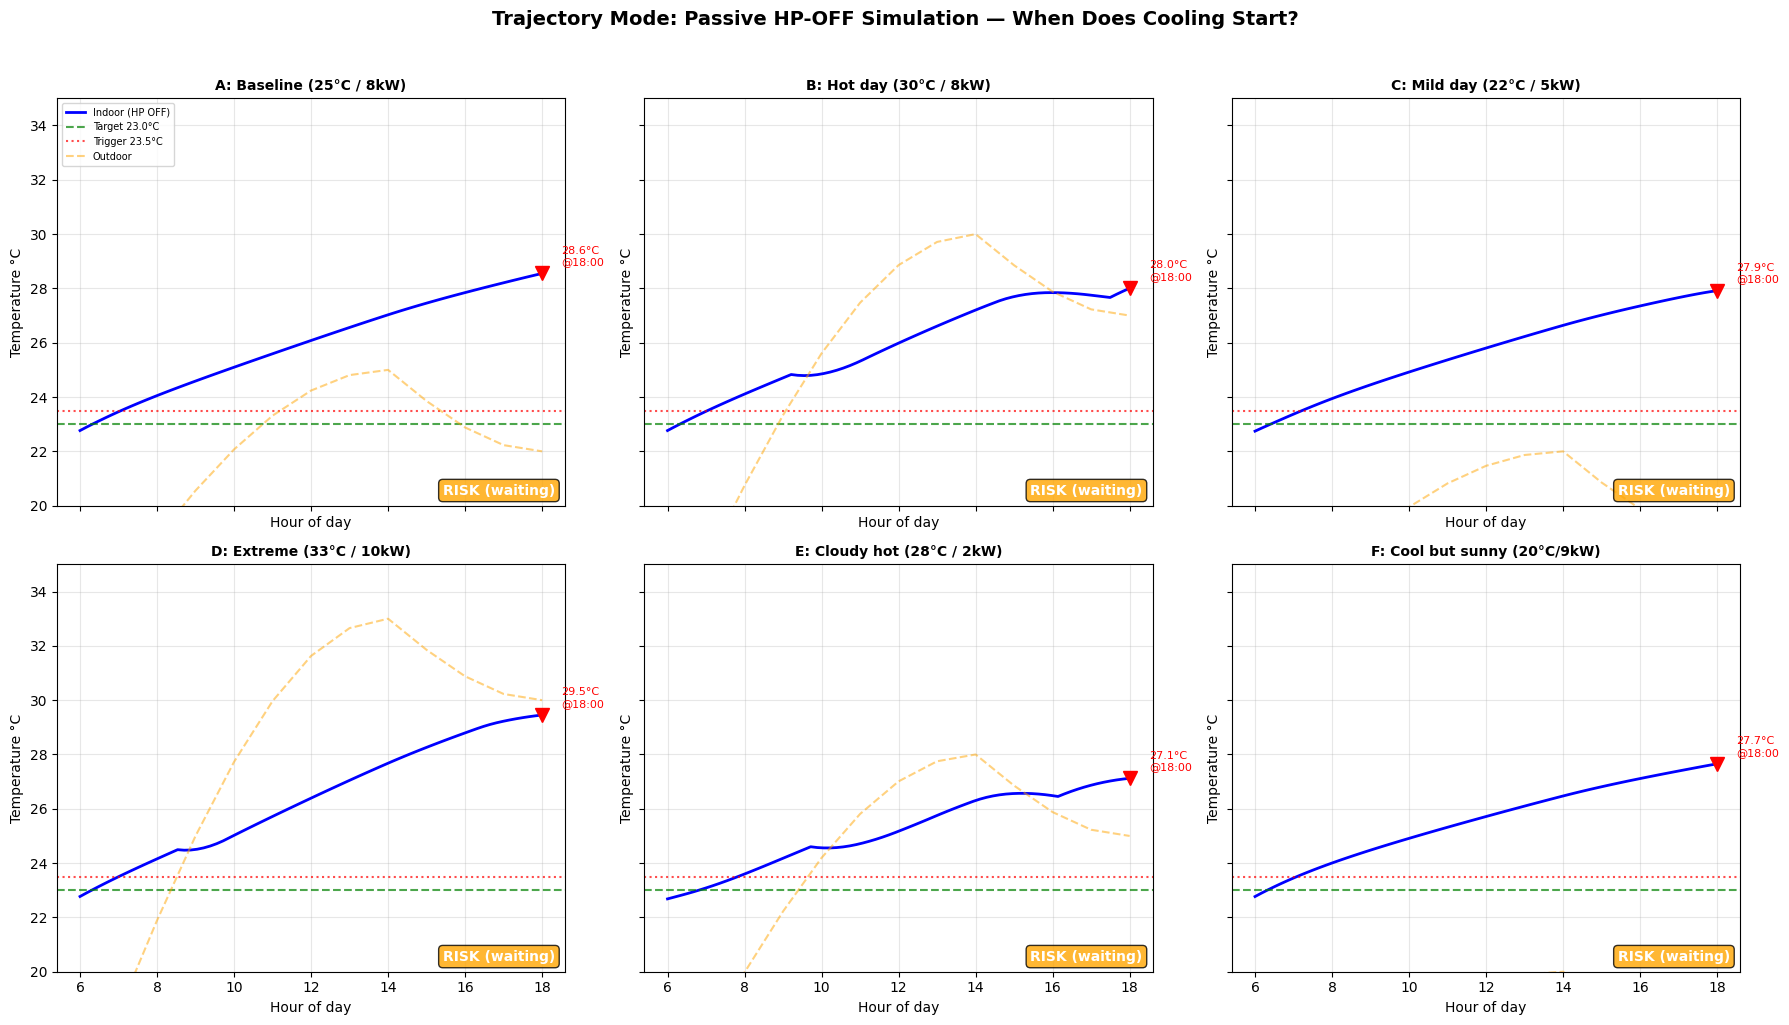

In [5]:
# === Plot all trajectory scenarios ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    traj = result.get('trajectory', [])
    if not traj:
        ax.set_title(f"{name}\n(no trajectory)", fontsize=9)
        continue
    
    # Time axis: 06:00 + hours
    params = list(scenarios.values())[idx]
    t_out, pv = build_forecasts(15.0, params['t_peak'], params['pv_peak'])
    
    # Trajectory times (10-min steps)
    n_steps = len(traj)
    hours = np.linspace(0, 12, n_steps)
    clock = [6 + h for h in hours]
    
    # Indoor trajectory
    ax.plot(clock, traj, 'b-', linewidth=2, label='Indoor (HP OFF)')
    
    # Target & threshold
    ax.axhline(COOLING_TARGET, color='green', linestyle='--', alpha=0.7, label=f'Target {COOLING_TARGET}°C')
    trigger = COOLING_TARGET + 0.5
    ax.axhline(trigger, color='red', linestyle=':', alpha=0.7, label=f'Trigger {trigger}°C')
    
    # Outdoor temp (secondary)
    out_hours = [6 + h for h in range(len(t_out))]
    ax.plot(out_hours, t_out, 'orange', linestyle='--', alpha=0.5, label='Outdoor')
    
    # Mark peak
    peak_clock = 6 + result['peak_hour']
    ax.plot(peak_clock, result['peak_temp'], 'rv', markersize=10)
    ax.annotate(f"{result['peak_temp']:.1f}°C\n@{peak_clock:.0f}:00",
                xy=(peak_clock, result['peak_temp']),
                xytext=(peak_clock + 0.5, result['peak_temp'] + 0.3),
                fontsize=8, color='red')
    
    # Decision badge
    badge_color = 'red' if result['should_cool_now'] else ('orange' if result['risk'] else 'green')
    badge_text = 'COOL NOW' if result['should_cool_now'] else ('RISK (waiting)' if result['risk'] else 'NO RISK')
    ax.text(0.98, 0.02, badge_text, transform=ax.transAxes, fontsize=10,
            fontweight='bold', color='white', ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=badge_color, alpha=0.8))
    
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylim(20, 35)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Temperature °C')
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Trajectory Mode: Passive HP-OFF Simulation — When Does Cooling Start?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5 — Model Mode: Equilibrium Outlet Temperature

The `ThermalEquilibriumModel.calculate_optimal_outlet_temperature` computes
what outlet temp the HP needs to send to reach or maintain the target.
In cooling mode, lower outlet = more cooling power.

We simulate each hour from 06:00 → 18:00, asking the model:
"Given current conditions, what outlet temp do I need?"

In [18]:
def simulate_model_mode(model, indoor_start, target, t_out_forecast, pv_forecast,
                        inlet_temp=24.0, step_minutes=10, horizon_hours=12,
                        window_event=None):
    """
    Simulate cooling over a day using the model's trajectory prediction.
    
    For each time step:
    1. Ask the model for the equilibrium outlet temp to maintain target
    2. Clamp to cooling range [18, 24] °C
    3. Run a 1-step trajectory to get next indoor temp
    4. Decide: if indoor < target - 0.3 → HP OFF (outlet = inlet)
    
    window_event: dict with {step: delta_K} — sudden indoor temp drop at that step
    """
    n_steps = int(horizon_hours * 60 / step_minutes)
    step_hours = step_minutes / 60.0
    
    current_indoor = indoor_start
    indoor_history = [current_indoor]
    outlet_history = []
    hp_state = []  # True = HP cooling, False = HP off
    outdoor_history = []
    pv_history_sim = []
    
    for step in range(n_steps):
        t_frac = step * step_hours  # hours since 06:00
        
        # Interpolate outdoor temp and PV for this step
        t_idx = t_frac  # forecast is hourly, index = hour
        i_lo = int(min(t_idx, len(t_out_forecast) - 2))
        i_hi = min(i_lo + 1, len(t_out_forecast) - 1)
        frac = t_idx - i_lo
        t_out_now = t_out_forecast[i_lo] + frac * (t_out_forecast[i_hi] - t_out_forecast[i_lo])
        pv_now = pv_forecast[i_lo] + frac * (pv_forecast[i_hi] - pv_forecast[i_lo])
        
        outdoor_history.append(t_out_now)
        pv_history_sim.append(pv_now)
        
        # Window event: sudden indoor temp drop
        if window_event and step in window_event:
            current_indoor += window_event[step]  # negative = cooling
        
        # Ask model: what outlet temp for equilibrium at target?
        eq_result = model.calculate_optimal_outlet_temperature(
            target_indoor=target,
            current_indoor=current_indoor,
            outdoor_temp=t_out_now,
            time_available_hours=step_hours,
            climate_mode='cooling',
            pv_power=pv_now,
            fireplace_on=0,
            tv_on=0,
        )
        
        if eq_result is None:
            outlet_temp = inlet_temp
        else:
            outlet_temp = eq_result['optimal_outlet_temp']
        
        # Cooling decision logic
        cooling_active = False
        if current_indoor > target - 0.3:  # close to or above target
            # Clamp to cooling range
            outlet_clamped = max(config.COOLING_CLAMP_MIN_ABS,
                                min(outlet_temp, config.COOLING_CLAMP_MAX_ABS))
            # Only cool if outlet would actually be below inlet
            if outlet_clamped < inlet_temp - config.MIN_COOLING_DELTA_K:
                outlet_temp = outlet_clamped
                cooling_active = True
            else:
                outlet_temp = inlet_temp  # HP off
        else:
            outlet_temp = inlet_temp  # HP off, room already cool enough
        
        outlet_history.append(outlet_temp)
        hp_state.append(cooling_active)
        
        # Simulate 1 step with the chosen outlet temp
        result = model.predict_thermal_trajectory(
            current_indoor=current_indoor,
            target_indoor=target,
            outlet_temp=outlet_temp,
            outdoor_temp=t_out_now,
            time_horizon_hours=step_hours,
            time_step_minutes=step_minutes,
            pv_power=pv_now,
            fireplace_on=0,
            tv_on=0,
            inlet_temp=inlet_temp,
            climate_mode='cooling',
            delta_t_floor=-2.0 if cooling_active else 0.0,
        )
        
        if result and result['trajectory']:
            current_indoor = result['trajectory'][-1]
        
        indoor_history.append(current_indoor)
    
    return {
        'indoor': indoor_history,
        'outlet': outlet_history,
        'hp_active': hp_state,
        'outdoor': outdoor_history,
        'pv': pv_history_sim,
        'n_steps': n_steps,
        'step_minutes': step_minutes,
    }

print("simulate_model_mode() defined — now with climate_mode='cooling'")

simulate_model_mode() defined — now with climate_mode='cooling'


In [19]:
# === Run model mode for all scenarios ===
model_results = {}
for name, params in scenarios.items():
    t_out, pv = build_forecasts(15.0, params['t_peak'], params['pv_peak'])
    sim = simulate_model_mode(model, INDOOR_START, COOLING_TARGET, t_out, pv, INLET_TEMP)
    model_results[name] = sim
    
    hp_on_steps = sum(sim['hp_active'])
    hp_on_minutes = hp_on_steps * sim['step_minutes']
    max_indoor = max(sim['indoor'])
    min_outlet = min(sim['outlet'])
    
    # Find first HP activation step
    first_hp = next((i for i, v in enumerate(sim['hp_active']) if v), None)
    first_hp_time = f"{6 + first_hp * sim['step_minutes'] / 60:.1f}" if first_hp is not None else "never"
    
    print(f"\n{name}")
    print(f"  HP first ON at:  {first_hp_time}:00")
    print(f"  HP total ON:     {hp_on_minutes:.0f} min ({hp_on_minutes/60:.1f} h)")
    print(f"  Max indoor:      {max_indoor:.2f} °C")
    print(f"  Min outlet used: {min_outlet:.1f} °C")
    print(f"  Indoor range:    {min(sim['indoor']):.2f} — {max_indoor:.2f} °C")


A: Baseline (25°C / 8kW)
  HP first ON at:  6.2:00
  HP total ON:     700 min (11.7 h)
  Max indoor:      23.67 °C
  Min outlet used: 18.0 °C
  Indoor range:    22.60 — 23.67 °C

B: Hot day (30°C / 8kW)
  HP first ON at:  6.2:00
  HP total ON:     700 min (11.7 h)
  Max indoor:      24.33 °C
  Min outlet used: 18.0 °C
  Indoor range:    22.60 — 24.33 °C

C: Mild day (22°C / 5kW)
  HP first ON at:  6.2:00
  HP total ON:     650 min (10.8 h)
  Max indoor:      23.19 °C
  Min outlet used: 18.0 °C
  Indoor range:    22.60 — 23.19 °C

D: Extreme (33°C / 10kW)
  HP first ON at:  6.2:00
  HP total ON:     700 min (11.7 h)
  Max indoor:      24.66 °C
  Min outlet used: 18.0 °C
  Indoor range:    22.60 — 24.66 °C

E: Cloudy hot (28°C / 2kW)
  HP first ON at:  6.5:00
  HP total ON:     690 min (11.5 h)
  Max indoor:      24.05 °C
  Min outlet used: 18.0 °C
  Indoor range:    22.60 — 24.05 °C

F: Cool but sunny (20°C/9kW)
  HP first ON at:  6.2:00
  HP total ON:     710 min (11.8 h)
  Max indoor

In [17]:
# === DIAGNOSTIC: Verify fix — model now returns cooling outlets ===
# After adding climate_mode='cooling' to calculate_optimal_outlet_temperature,
# the model uses cooling bounds [18, 24] instead of heating bounds [outdoor+5, 70].

# Reload module to pick up production code changes
import importlib
from src import thermal_equilibrium_model as _tem_mod
importlib.reload(_tem_mod)

# Rebuild model with cooling parameters (same as cell 2)
state_file = os.path.join(ROOT, 'Logs', 'unified_thermal_state_cooling.json')
with open(state_file) as f:
    cooling_state = json.load(f)
bp = cooling_state['baseline_parameters']
model = _tem_mod.ThermalEquilibriumModel()
model.thermal_time_constant = bp['thermal_time_constant']
model.heat_loss_coefficient = bp['heat_loss_coefficient']
model.outlet_effectiveness = bp['outlet_effectiveness']
model.slab_time_constant_hours = bp['slab_time_constant_hours']
model.external_source_weights['pv'] = bp['pv_heat_weight']
model.external_source_weights['fireplace'] = bp['fireplace_heat_weight']
model.external_source_weights['tv'] = bp['tv_heat_weight']
model.delta_t_floor = bp.get('delta_t_floor', 2.0)
model.solar_lag_minutes = bp.get('solar_lag_minutes', 45.0)

t_out_diag, pv_diag = build_forecasts(15.0, 30.0, 8000)

print("=== AFTER FIX: calculate_optimal_outlet_temperature(climate_mode='cooling') ===\n")
print(f"  Cooling bounds: [{config.COOLING_CLAMP_MIN_ABS}, {config.COOLING_CLAMP_MAX_ABS}]")
print(f"  HP gate: outlet < {INLET_TEMP - config.MIN_COOLING_DELTA_K}")
print()
print(f"{'Hour':>5} | {'Indoor':>7} | {'Out':>5} | {'Model says':>10} | {'< 22.0?':>8}")
print("-" * 55)
current = INDOOR_START
for h in range(13):
    eq = model.calculate_optimal_outlet_temperature(
        target_indoor=COOLING_TARGET, current_indoor=current,
        outdoor_temp=t_out_diag[h], time_available_hours=1/6,
        climate_mode='cooling',
        pv_power=pv_diag[h], fireplace_on=0, tv_on=0)
    raw = eq['optimal_outlet_temp'] if eq else INLET_TEMP
    gate = INLET_TEMP - config.MIN_COOLING_DELTA_K
    print(f" {6+h:02d}:00 | {current:7.2f} | {t_out_diag[h]:5.1f} | {raw:10.1f} | {'YES ❄️' if raw < gate else 'NO':>8}")
    current += 0.1 * (t_out_diag[h] - current) / model.thermal_time_constant

=== AFTER FIX: calculate_optimal_outlet_temperature(climate_mode='cooling') ===

  Cooling bounds: [18.0, 24.0]
  HP gate: outlet < 22.0

 Hour |  Indoor |   Out | Model says |  < 22.0?
-------------------------------------------------------
 06:00 |   22.60 |  15.0 |       18.1 |   YES ❄️
 07:00 |   22.35 |  17.9 |       18.0 |   YES ❄️
 08:00 |   22.20 |  20.7 |       18.0 |   YES ❄️
 09:00 |   22.15 |  23.3 |       18.0 |   YES ❄️
 10:00 |   22.19 |  25.6 |       18.0 |   YES ❄️
 11:00 |   22.30 |  27.5 |       18.0 |   YES ❄️
 12:00 |   22.48 |  28.9 |       18.0 |   YES ❄️
 13:00 |   22.69 |  29.7 |       18.0 |   YES ❄️
 14:00 |   22.92 |  30.0 |       18.0 |   YES ❄️
 15:00 |   23.16 |  28.9 |       18.0 |   YES ❄️
 16:00 |   23.35 |  27.9 |       18.0 |   YES ❄️
 17:00 |   23.50 |  27.2 |       18.0 |   YES ❄️
 18:00 |   23.62 |  27.0 |       18.0 |   YES ❄️


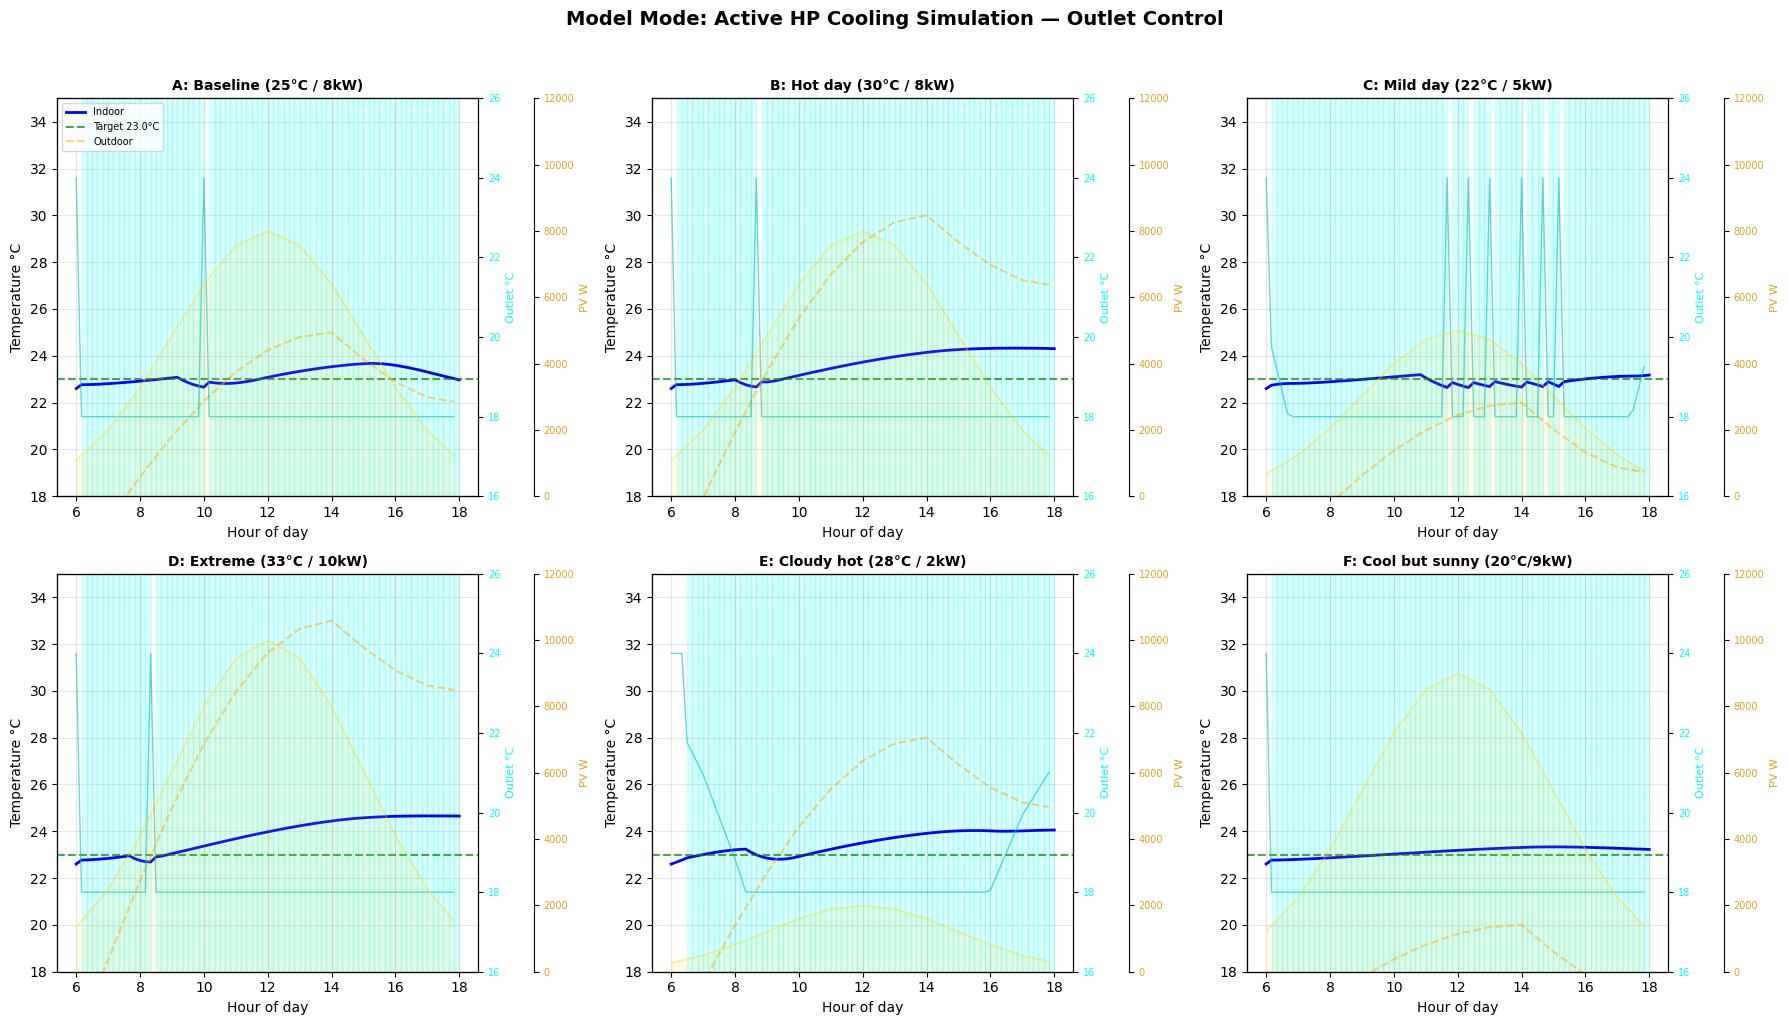

In [20]:
# === Plot Model Mode — All Scenarios ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, sim) in enumerate(model_results.items()):
    ax = axes[idx]
    n = sim['n_steps']
    step_h = sim['step_minutes'] / 60.0
    clock = [6 + i * step_h for i in range(n + 1)]  # indoor has n+1 points
    clock_steps = [6 + i * step_h for i in range(n)]  # outlet/hp has n points
    
    # Indoor trajectory
    ax.plot(clock, sim['indoor'], 'b-', linewidth=2, label='Indoor')
    ax.axhline(COOLING_TARGET, color='green', linestyle='--', alpha=0.7, label=f'Target {COOLING_TARGET}°C')
    
    # Outdoor
    ax.plot(clock_steps, sim['outdoor'], 'orange', linestyle='--', alpha=0.5, label='Outdoor')
    
    # HP active regions (shading)
    for i in range(n):
        if sim['hp_active'][i]:
            ax.axvspan(clock_steps[i], clock_steps[i] + step_h,
                       alpha=0.15, color='cyan')
    
    # Outlet temp on twin axis
    ax2 = ax.twinx()
    ax2.plot(clock_steps, sim['outlet'], 'c-', alpha=0.6, linewidth=1, label='Outlet')
    ax2.set_ylim(16, 26)
    ax2.set_ylabel('Outlet °C', color='cyan', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='cyan', labelsize=7)
    
    # PV on separate scale
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 40))
    ax3.fill_between(clock_steps, sim['pv'], alpha=0.1, color='gold')
    ax3.plot(clock_steps, sim['pv'], color='gold', alpha=0.4, linewidth=1)
    ax3.set_ylim(0, 12000)
    ax3.set_ylabel('PV W', color='goldenrod', fontsize=8)
    ax3.tick_params(axis='y', labelcolor='goldenrod', labelsize=7)
    
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylim(18, 35)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Temperature °C')
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Model Mode: Active HP Cooling Simulation — Outlet Control',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6 — Open Window Disturbance: Sudden −1 K Drop

Simulate a sudden indoor temperature drop of 1 K (open windows at ~10:00),
followed by windows closing after 30 minutes.
Compare trajectory mode (HP OFF) and model mode (HP reacting).

In [21]:
# === Window event at step 24 = 4h after start = 10:00 ===
# Each step = 10 min, so step 24 = 240 min = 4h → 10:00
# Drop of -1K applied instantly (window opened)
WINDOW_STEP = 24  # 10:00
window_event = {WINDOW_STEP: -1.0}  # -1K instant drop

# Use baseline scenario (25°C / 8kW)
t_out_base, pv_base = build_forecasts(15.0, 25.0, 8000)

# --- Trajectory mode: HP OFF with window event ---
# Simulate by running trajectory in segments
traj_no_window = model.predict_thermal_trajectory(
    current_indoor=INDOOR_START,
    target_indoor=COOLING_TARGET,
    outlet_temp=INLET_TEMP,  # HP OFF
    outdoor_temp=t_out_base,
    time_horizon_hours=12.0,
    time_step_minutes=10,
    pv_power=0,
    pv_forecasts=pv_base,
    fireplace_on=0, tv_on=0,
    inlet_temp=INLET_TEMP,
    climate_mode='cooling',
    delta_t_floor=0.0,
)

# Trajectory with window: run first 24 steps, apply drop, then continue
step_minutes = 10
step_hours = step_minutes / 60.0

# Segment 1: 0 → WINDOW_STEP
seg1 = model.predict_thermal_trajectory(
    current_indoor=INDOOR_START,
    target_indoor=COOLING_TARGET,
    outlet_temp=INLET_TEMP,
    outdoor_temp=t_out_base,
    time_horizon_hours=WINDOW_STEP * step_hours,
    time_step_minutes=step_minutes,
    pv_power=0,
    pv_forecasts=pv_base,
    fireplace_on=0, tv_on=0,
    inlet_temp=INLET_TEMP,
    climate_mode='cooling',
    delta_t_floor=0.0,
)

indoor_at_window = seg1['trajectory'][-1] - 1.0  # Apply -1K drop

# Build remaining outdoor/PV forecasts from window step onward
remaining_hours = 12.0 - WINDOW_STEP * step_hours
# Shift forecast to start from current position
t_out_remaining = t_out_base[int(WINDOW_STEP * step_hours):]
pv_remaining = pv_base[int(WINDOW_STEP * step_hours):]
if not t_out_remaining:
    t_out_remaining = [t_out_base[-1]]
if not pv_remaining:
    pv_remaining = [pv_base[-1]]

seg2 = model.predict_thermal_trajectory(
    current_indoor=indoor_at_window,
    target_indoor=COOLING_TARGET,
    outlet_temp=INLET_TEMP,
    outdoor_temp=t_out_remaining,
    time_horizon_hours=remaining_hours,
    time_step_minutes=step_minutes,
    pv_power=pv_remaining[0],
    pv_forecasts=pv_remaining,
    fireplace_on=0, tv_on=0,
    inlet_temp=INLET_TEMP,
    climate_mode='cooling',
    delta_t_floor=0.0,
)

traj_with_window = seg1['trajectory'] + seg2['trajectory']

# --- Model mode: HP reacting to window event ---
sim_no_window = simulate_model_mode(model, INDOOR_START, COOLING_TARGET,
                                     t_out_base, pv_base, INLET_TEMP)
sim_with_window = simulate_model_mode(model, INDOOR_START, COOLING_TARGET,
                                       t_out_base, pv_base, INLET_TEMP,
                                       window_event=window_event)

print(f"Window event at step {WINDOW_STEP} = 10:00")
print(f"Indoor before window: {seg1['trajectory'][-1]:.2f} °C")
print(f"Indoor after  window: {indoor_at_window:.2f} °C (−1.0 K)")
print(f"\nTrajectory mode (HP OFF):")
print(f"  Without window: peak = {max(traj_no_window['trajectory']):.2f} °C")
print(f"  With    window: peak = {max(traj_with_window):.2f} °C")
print(f"\nModel mode (HP reacting):")
print(f"  Without window: max = {max(sim_no_window['indoor']):.2f} °C, HP ON = {sum(sim_no_window['hp_active']) * 10} min")
print(f"  With    window: max = {max(sim_with_window['indoor']):.2f} °C, HP ON = {sum(sim_with_window['hp_active']) * 10} min")

Window event at step 24 = 10:00
Indoor before window: 24.97 °C
Indoor after  window: 23.97 °C (−1.0 K)

Trajectory mode (HP OFF):
  Without window: peak = 28.49 °C
  With    window: peak = 27.21 °C

Model mode (HP reacting):
  Without window: max = 23.67 °C, HP ON = 700 min
  With    window: max = 23.68 °C, HP ON = 660 min


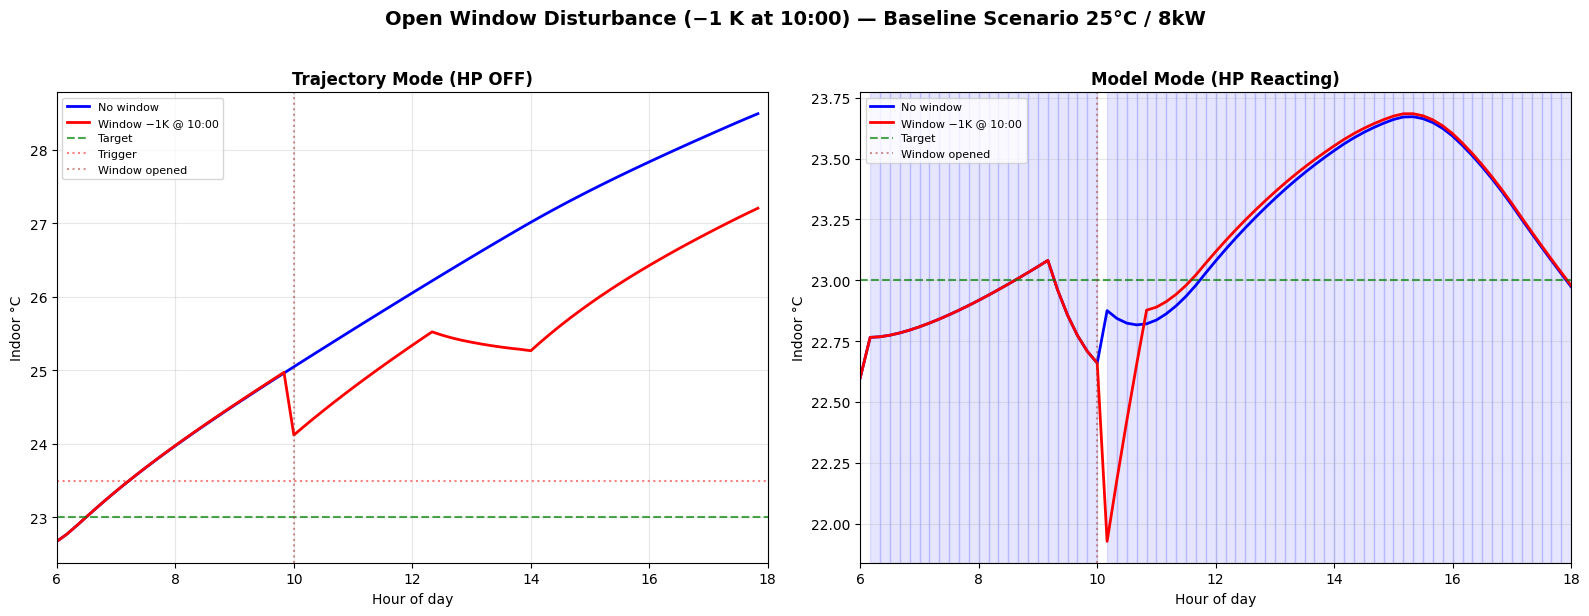

In [22]:
# === Plot: Window Disturbance Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Trajectory Mode (HP OFF) ---
ax = axes[0]
n_no = len(traj_no_window['trajectory'])
n_win = len(traj_with_window)
clock_no = [6 + i * step_hours for i in range(n_no)]
clock_win = [6 + i * step_hours for i in range(n_win)]

ax.plot(clock_no, traj_no_window['trajectory'], 'b-', linewidth=2, label='No window')
ax.plot(clock_win, traj_with_window, 'r-', linewidth=2, label='Window −1K @ 10:00')
ax.axhline(COOLING_TARGET, color='green', linestyle='--', alpha=0.7, label='Target')
ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', alpha=0.5, label='Trigger')
ax.axvline(10.0, color='brown', linestyle=':', alpha=0.5, label='Window opened')
ax.set_title('Trajectory Mode (HP OFF)', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Indoor °C')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(6, 18)

# --- Right: Model Mode (HP reacting) ---
ax = axes[1]
n = sim_no_window['n_steps']
clock = [6 + i * step_hours for i in range(n + 1)]
clock_s = [6 + i * step_hours for i in range(n)]

ax.plot(clock, sim_no_window['indoor'], 'b-', linewidth=2, label='No window')
ax.plot(clock, sim_with_window['indoor'], 'r-', linewidth=2, label='Window −1K @ 10:00')
ax.axhline(COOLING_TARGET, color='green', linestyle='--', alpha=0.7, label='Target')
ax.axvline(10.0, color='brown', linestyle=':', alpha=0.5, label='Window opened')

# Shade HP active regions for window scenario
for i in range(n):
    if sim_with_window['hp_active'][i] and not sim_no_window['hp_active'][i]:
        ax.axvspan(clock_s[i], clock_s[i] + step_hours, alpha=0.2, color='cyan', label='_')
    elif sim_no_window['hp_active'][i]:
        ax.axvspan(clock_s[i], clock_s[i] + step_hours, alpha=0.1, color='blue', label='_')

ax.set_title('Model Mode (HP Reacting)', fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Indoor °C')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(6, 18)

fig.suptitle('Open Window Disturbance (−1 K at 10:00) — Baseline Scenario 25°C / 8kW',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7 — Summary Table: All Scenarios Side by Side

In [23]:
# === Summary comparison: Trajectory vs Model mode ===
rows = []
for name in scenarios:
    traj_r = results[name]
    model_r = model_results[name]
    
    # Trajectory mode
    traj_peak = traj_r['peak_temp']
    traj_peak_h = traj_r['peak_hour']
    traj_cool = traj_r['should_cool_now']
    traj_risk = traj_r['risk']
    
    # Model mode
    model_max = max(model_r['indoor'])
    model_hp_min = sum(model_r['hp_active']) * model_r['step_minutes']
    first_hp = next((i for i, v in enumerate(model_r['hp_active']) if v), None)
    model_hp_start = f"{6 + first_hp * model_r['step_minutes'] / 60:.1f}" if first_hp is not None else "—"
    
    params = scenarios[name]
    rows.append({
        'Scenario': name.split(': ')[1] if ': ' in name else name,
        'T_out peak': f"{params['t_peak']}°C",
        'PV peak': f"{params['pv_peak']}W",
        '(Traj) Peak': f"{traj_peak:.1f}°C",
        '(Traj) Peak@': f"{6+traj_peak_h:.0f}:00",
        '(Traj) Risk': '⚠️' if traj_risk else '✅',
        '(Traj) Cool?': '❄️ YES' if traj_cool else 'No',
        '(Model) Max': f"{model_max:.1f}°C",
        '(Model) HP ON': f"{model_hp_min:.0f} min",
        '(Model) HP start': model_hp_start,
    })

df_summary = pd.DataFrame(rows)
print("\n" + "=" * 120)
print("  COOLING SCENARIO SUMMARY — Trajectory Mode vs Model Mode")
print("=" * 120)
print(f"  Start: 06:00 | Indoor: {INDOOR_START}°C | Outdoor: 15°C | PV: 0W")
print(f"  Target: {COOLING_TARGET}°C | Lead time: {config.PRE_COOL_LEAD_TIME_HOURS}h")
print(f"  Outlet range: [{config.COOLING_CLAMP_MIN_ABS}, {config.COOLING_CLAMP_MAX_ABS}] °C")
print("=" * 120)
print(df_summary.to_string(index=False))
print("=" * 120)


  COOLING SCENARIO SUMMARY — Trajectory Mode vs Model Mode
  Start: 06:00 | Indoor: 22.6°C | Outdoor: 15°C | PV: 0W
  Target: 23.0°C | Lead time: 8.0h
  Outlet range: [18.0, 24.0] °C
                 Scenario T_out peak PV peak (Traj) Peak (Traj) Peak@ (Traj) Risk (Traj) Cool? (Model) Max (Model) HP ON (Model) HP start
    Baseline (25°C / 8kW)     25.0°C   8000W      28.6°C        18:00          ⚠️           No      23.7°C       700 min              6.2
     Hot day (30°C / 8kW)     30.0°C   8000W      28.0°C        18:00          ⚠️           No      24.3°C       700 min              6.2
    Mild day (22°C / 5kW)     22.0°C   5000W      27.9°C        18:00          ⚠️           No      23.2°C       650 min              6.2
    Extreme (33°C / 10kW)     33.0°C  10000W      29.5°C        18:00          ⚠️           No      24.7°C       700 min              6.2
  Cloudy hot (28°C / 2kW)     28.0°C   2000W      27.1°C        18:00          ⚠️           No      24.1°C       690 min      

## 8 — Sensitivity: Varying Outdoor Temperature at 12:00

Fix PV at 8000W, sweep outdoor peak from 18°C to 35°C.
Show when pre-cooling triggers and how much HP runtime is needed.

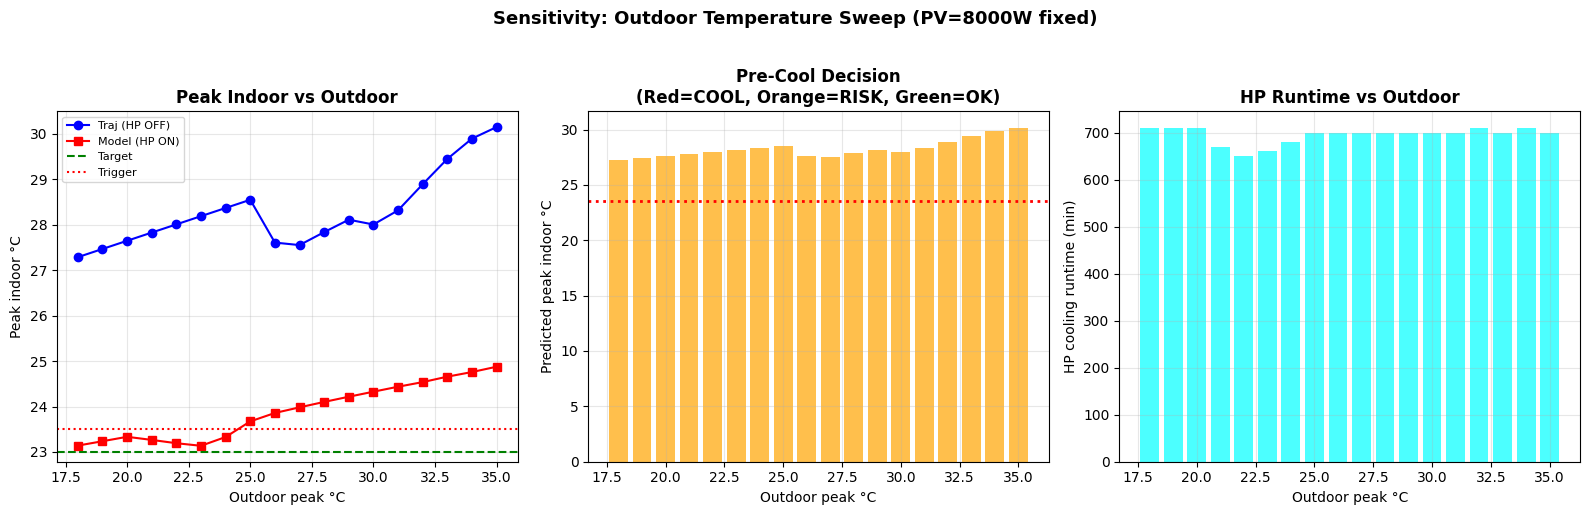

In [24]:
t_peaks = np.arange(18, 36, 1)
pv_fix = 8000

sweep_traj = []
sweep_model = []

for t_pk in t_peaks:
    t_out, pv = build_forecasts(15.0, float(t_pk), pv_fix)
    features = build_features(t_out, pv, INDOOR_START, INLET_TEMP)
    
    # Trajectory mode
    r = predictor.predict_overheating_risk(
        current_indoor=INDOOR_START, target_cooling=COOLING_TARGET,
        features=features, thermal_model=model, climate_mode='cooling')
    sweep_traj.append({
        't_peak': t_pk,
        'peak_temp': r['peak_temp'],
        'risk': r['risk'],
        'cool_now': r['should_cool_now'],
    })
    
    # Model mode
    sim = simulate_model_mode(model, INDOOR_START, COOLING_TARGET, t_out, pv, INLET_TEMP)
    sweep_model.append({
        't_peak': t_pk,
        'max_indoor': max(sim['indoor']),
        'hp_minutes': sum(sim['hp_active']) * sim['step_minutes'],
    })

df_traj = pd.DataFrame(sweep_traj)
df_model = pd.DataFrame(sweep_model)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Peak indoor temp vs outdoor
ax = axes[0]
ax.plot(df_traj['t_peak'], df_traj['peak_temp'], 'bo-', label='Traj (HP OFF)')
ax.plot(df_model['t_peak'], df_model['max_indoor'], 'rs-', label='Model (HP ON)')
ax.axhline(COOLING_TARGET, color='green', linestyle='--', label='Target')
ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', label='Trigger')
ax.set_xlabel('Outdoor peak °C')
ax.set_ylabel('Peak indoor °C')
ax.set_title('Peak Indoor vs Outdoor', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Pre-cool decision
ax = axes[1]
colors = ['red' if r else 'orange' if rk else 'green'
          for r, rk in zip(df_traj['cool_now'], df_traj['risk'])]
ax.bar(df_traj['t_peak'], df_traj['peak_temp'], color=colors, alpha=0.7)
ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', linewidth=2)
ax.set_xlabel('Outdoor peak °C')
ax.set_ylabel('Predicted peak indoor °C')
ax.set_title('Pre-Cool Decision\n(Red=COOL, Orange=RISK, Green=OK)', fontweight='bold')
ax.grid(True, alpha=0.3)

# HP runtime
ax = axes[2]
ax.bar(df_model['t_peak'], df_model['hp_minutes'], color='cyan', alpha=0.7)
ax.set_xlabel('Outdoor peak °C')
ax.set_ylabel('HP cooling runtime (min)')
ax.set_title('HP Runtime vs Outdoor', fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Sensitivity: Outdoor Temperature Sweep (PV={pv_fix}W fixed)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9 — Sensitivity: Varying PV at 12:00

Fix outdoor peak at 25°C, sweep PV from 0 to 12 000 W.

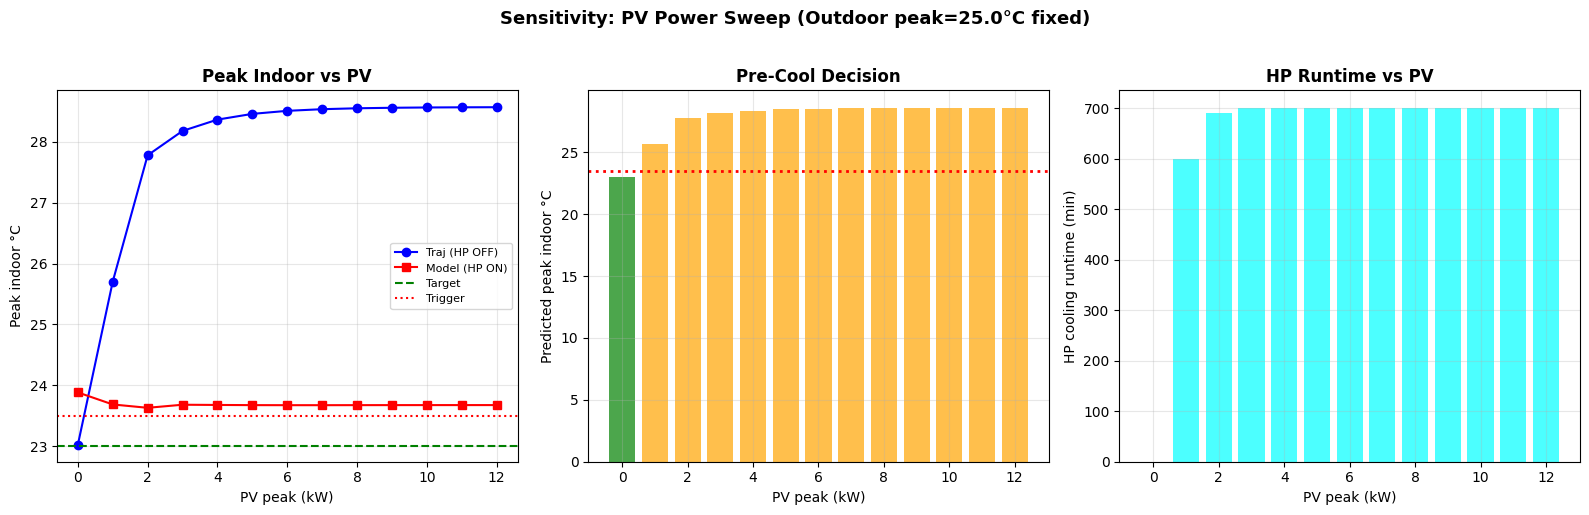

In [25]:
pv_peaks = np.arange(0, 13000, 1000)
t_fix = 25.0

sweep_pv_traj = []
sweep_pv_model = []

for pv_pk in pv_peaks:
    t_out, pv = build_forecasts(15.0, t_fix, float(pv_pk))
    features = build_features(t_out, pv, INDOOR_START, INLET_TEMP)
    
    r = predictor.predict_overheating_risk(
        current_indoor=INDOOR_START, target_cooling=COOLING_TARGET,
        features=features, thermal_model=model, climate_mode='cooling')
    sweep_pv_traj.append({
        'pv_peak': pv_pk,
        'peak_temp': r['peak_temp'],
        'risk': r['risk'],
        'cool_now': r['should_cool_now'],
    })
    
    sim = simulate_model_mode(model, INDOOR_START, COOLING_TARGET, t_out, pv, INLET_TEMP)
    sweep_pv_model.append({
        'pv_peak': pv_pk,
        'max_indoor': max(sim['indoor']),
        'hp_minutes': sum(sim['hp_active']) * sim['step_minutes'],
    })

df_pv_traj = pd.DataFrame(sweep_pv_traj)
df_pv_model = pd.DataFrame(sweep_pv_model)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(df_pv_traj['pv_peak']/1000, df_pv_traj['peak_temp'], 'bo-', label='Traj (HP OFF)')
ax.plot(df_pv_model['pv_peak']/1000, df_pv_model['max_indoor'], 'rs-', label='Model (HP ON)')
ax.axhline(COOLING_TARGET, color='green', linestyle='--', label='Target')
ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', label='Trigger')
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('Peak indoor °C')
ax.set_title('Peak Indoor vs PV', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = ['red' if r else 'orange' if rk else 'green'
          for r, rk in zip(df_pv_traj['cool_now'], df_pv_traj['risk'])]
ax.bar(df_pv_traj['pv_peak']/1000, df_pv_traj['peak_temp'], color=colors, alpha=0.7, width=0.8)
ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', linewidth=2)
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('Predicted peak indoor °C')
ax.set_title('Pre-Cool Decision', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.bar(df_pv_model['pv_peak']/1000, df_pv_model['hp_minutes'], color='cyan', alpha=0.7, width=0.8)
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('HP cooling runtime (min)')
ax.set_title('HP Runtime vs PV', fontweight='bold')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Sensitivity: PV Power Sweep (Outdoor peak={t_fix}°C fixed)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10 — Heat Map: Outdoor × PV Decision Matrix

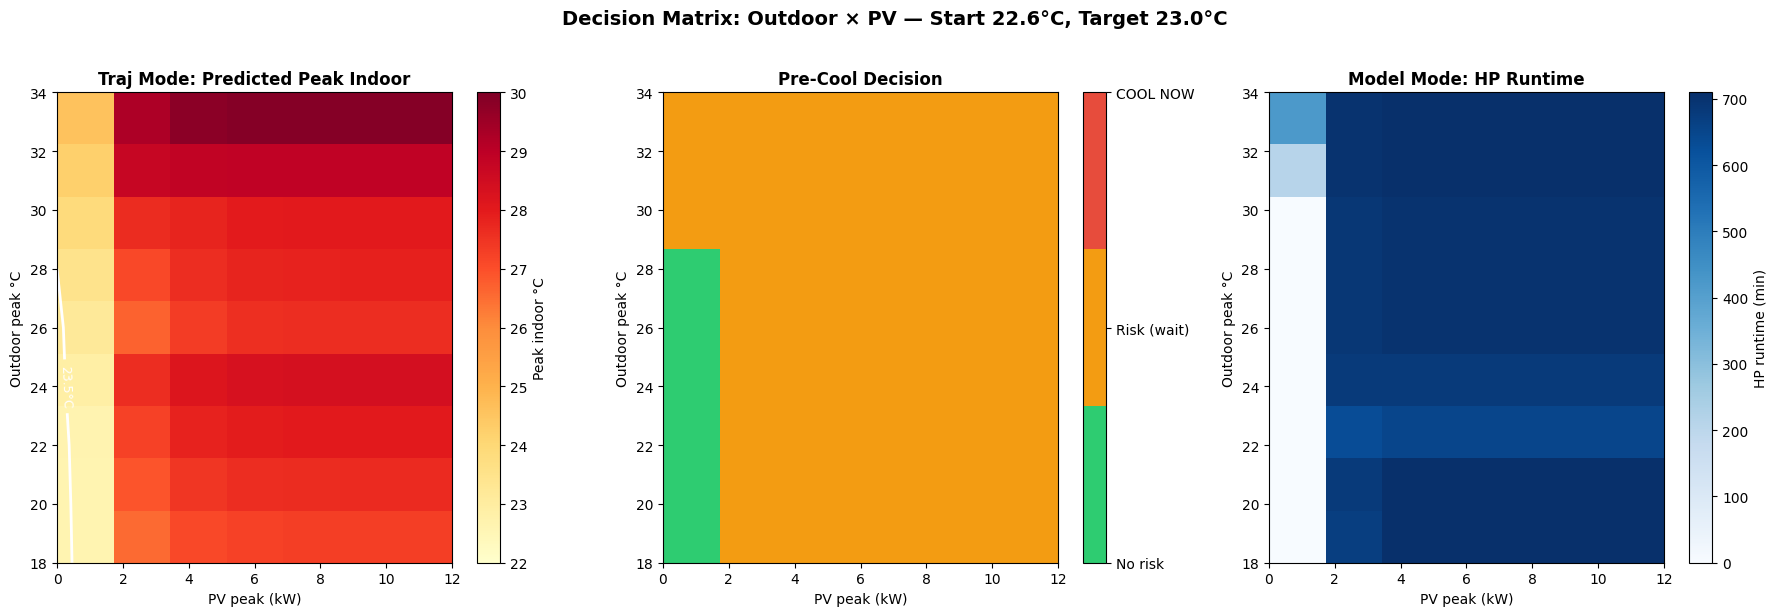

In [26]:
# 2D sweep: outdoor peak × PV peak → peak indoor temp & pre-cool decision
t_range = np.arange(18, 36, 2)
pv_range = np.arange(0, 13000, 2000)

peak_matrix = np.zeros((len(t_range), len(pv_range)))
cool_matrix = np.zeros((len(t_range), len(pv_range)))
hp_min_matrix = np.zeros((len(t_range), len(pv_range)))

for i, t_pk in enumerate(t_range):
    for j, pv_pk in enumerate(pv_range):
        t_out, pv = build_forecasts(15.0, float(t_pk), float(pv_pk))
        features = build_features(t_out, pv, INDOOR_START, INLET_TEMP)
        
        r = predictor.predict_overheating_risk(
            current_indoor=INDOOR_START, target_cooling=COOLING_TARGET,
            features=features, thermal_model=model, climate_mode='cooling')
        peak_matrix[i, j] = r['peak_temp']
        cool_matrix[i, j] = 2 if r['should_cool_now'] else (1 if r['risk'] else 0)
        
        sim = simulate_model_mode(model, INDOOR_START, COOLING_TARGET, t_out, pv, INLET_TEMP)
        hp_min_matrix[i, j] = sum(sim['hp_active']) * sim['step_minutes']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Peak temperature heatmap
ax = axes[0]
im = ax.imshow(peak_matrix, aspect='auto', origin='lower',
               extent=[pv_range[0]/1000, pv_range[-1]/1000, t_range[0], t_range[-1]],
               cmap='YlOrRd', vmin=22, vmax=30)
plt.colorbar(im, ax=ax, label='Peak indoor °C')
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('Outdoor peak °C')
ax.set_title('Traj Mode: Predicted Peak Indoor', fontweight='bold')

# Add contour for trigger threshold
cs = ax.contour(pv_range/1000, t_range, peak_matrix,
                levels=[COOLING_TARGET + 0.5], colors='white', linewidths=2)
ax.clabel(cs, fmt='%.1f°C', fontsize=9)

# Decision heatmap
ax = axes[1]
from matplotlib.colors import ListedColormap
cmap_decision = ListedColormap(['#2ecc71', '#f39c12', '#e74c3c'])
im2 = ax.imshow(cool_matrix, aspect='auto', origin='lower',
                extent=[pv_range[0]/1000, pv_range[-1]/1000, t_range[0], t_range[-1]],
                cmap=cmap_decision, vmin=0, vmax=2)
cbar2 = plt.colorbar(im2, ax=ax, ticks=[0, 1, 2])
cbar2.set_ticklabels(['No risk', 'Risk (wait)', 'COOL NOW'])
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('Outdoor peak °C')
ax.set_title('Pre-Cool Decision', fontweight='bold')

# HP runtime heatmap
ax = axes[2]
im3 = ax.imshow(hp_min_matrix, aspect='auto', origin='lower',
                extent=[pv_range[0]/1000, pv_range[-1]/1000, t_range[0], t_range[-1]],
                cmap='Blues', vmin=0)
plt.colorbar(im3, ax=ax, label='HP runtime (min)')
ax.set_xlabel('PV peak (kW)')
ax.set_ylabel('Outdoor peak °C')
ax.set_title('Model Mode: HP Runtime', fontweight='bold')

fig.suptitle(f'Decision Matrix: Outdoor × PV — Start {INDOOR_START}°C, Target {COOLING_TARGET}°C',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11 — Mode Comparison: Which Triggers Earlier?

The two modes serve fundamentally different roles:

| Mode | Strategy | Decision input |
|---|---|---|
| **Trajectory** (`OverheatingPredictor`) | Predictive pre-cooler — looks hours ahead at forecast | Future outdoor, PV, lead time |
| **Model** (`simulate_model_mode`) | Reactive controller — responds to current indoor temp | Current indoor vs. target |

**Key question:** If we run both in parallel, which one sends the first "start cooling" signal, and by how many minutes?

**Method:** The trajectory predictor is re-evaluated at every 10-min step with updated indoor temp (rising passively, HP OFF) and the remaining outdoor/PV forecast. The first step where `should_cool_now=True` is its trigger time. Model mode trigger is the first step where `hp_active=True`.

In [27]:
def find_trajectory_trigger(model, predictor, indoor_start, target, t_out_forecast,
                             pv_forecast, inlet_temp=24.0, step_minutes=10, horizon_hours=12):
    """
    Run the trajectory predictor at each time step with passively rising indoor temp (HP OFF).
    Returns the first step/hour where should_cool_now=True and the full passive trajectory.
    """
    n_steps = int(horizon_hours * 60 / step_minutes)
    step_hours = step_minutes / 60.0

    current_indoor = indoor_start
    indoor_passive = [current_indoor]
    trigger_step = None
    trigger_hour = None

    for step in range(n_steps):
        t_frac = step * step_hours
        i_lo = int(min(t_frac, len(t_out_forecast) - 2))
        i_hi = min(i_lo + 1, len(t_out_forecast) - 1)
        frac = t_frac - i_lo
        t_out_now = t_out_forecast[i_lo] + frac * (t_out_forecast[i_hi] - t_out_forecast[i_lo])
        pv_now = pv_forecast[i_lo] + frac * (pv_forecast[i_hi] - pv_forecast[i_lo])

        # Build features from the REMAINING forecast (current step onward)
        rem_idx = int(t_frac)
        t_rem = t_out_forecast[rem_idx:] if rem_idx < len(t_out_forecast) else [t_out_forecast[-1]]
        pv_rem = pv_forecast[rem_idx:] if rem_idx < len(pv_forecast) else [pv_forecast[-1]]
        features_now = build_features(t_rem, pv_rem, current_indoor, inlet_temp)

        r = predictor.predict_overheating_risk(
            current_indoor=current_indoor,
            target_cooling=target,
            features=features_now,
            thermal_model=model,
            climate_mode='cooling',
        )
        if r['should_cool_now'] and trigger_step is None:
            trigger_step = step
            trigger_hour = 6.0 + step * step_hours

        # Passive step: HP OFF, outdoor heat drives indoor up
        res = model.predict_thermal_trajectory(
            current_indoor=current_indoor,
            target_indoor=target,
            outlet_temp=inlet_temp,  # HP OFF
            outdoor_temp=t_out_now,
            time_horizon_hours=step_hours,
            time_step_minutes=step_minutes,
            pv_power=pv_now,
            fireplace_on=0, tv_on=0,
            inlet_temp=inlet_temp,
            climate_mode='cooling',
            delta_t_floor=0.0,
        )
        if res and res['trajectory']:
            current_indoor = res['trajectory'][-1]
        indoor_passive.append(current_indoor)

    return {
        'trigger_step': trigger_step,
        'trigger_hour': trigger_hour,
        'triggered': trigger_step is not None,
        'indoor_passive': indoor_passive,
    }


# Run both modes for all scenarios
step_h = 10 / 60.0
comparison_rows = []
traj_triggers = {}

for name, params in scenarios.items():
    t_out, pv = build_forecasts(15.0, params['t_peak'], params['pv_peak'])

    # Trajectory mode: find first predictor trigger
    trig = find_trajectory_trigger(model, predictor, INDOOR_START, COOLING_TARGET,
                                    t_out, pv, INLET_TEMP)
    traj_triggers[name] = trig

    # Model mode: first HP activation (from model_results)
    model_r = model_results[name]
    first_model = next((i for i, v in enumerate(model_r['hp_active']) if v), None)
    model_trigger_h = (6.0 + first_model * step_h) if first_model is not None else None

    traj_h = trig['trigger_hour']
    if traj_h is not None and model_trigger_h is not None:
        delta_min = (model_trigger_h - traj_h) * 60
        winner = 'Trajectory earlier' if traj_h < model_trigger_h else ('Same time' if delta_min == 0 else 'Model earlier')
    elif traj_h is None and model_trigger_h is not None:
        delta_min = None
        winner = 'Traj: never triggers'
    elif model_trigger_h is None:
        delta_min = None
        winner = 'Model: never triggers'
    else:
        delta_min = None
        winner = 'Neither triggers'

    comparison_rows.append({
        'Scenario': name.split(': ')[1] if ': ' in name else name,
        'Traj trigger': f"{traj_h:.1f}:00" if traj_h else '—',
        'Model trigger': f"{model_trigger_h:.1f}:00" if model_trigger_h else '—',
        'Δ (min)': f"{delta_min:+.0f}" if delta_min is not None else '—',
        'Earlier': winner,
        'Passive peak': f"{max(trig['indoor_passive']):.1f}°C",
        'Model max': f"{max(model_results[name]['indoor']):.1f}°C",
        'HP ON (model)': f"{sum(model_results[name]['hp_active']) * 10} min",
    })

df_comp = pd.DataFrame(comparison_rows)
print("=" * 110)
print("  MODE COMPARISON — Trajectory (Predictive) vs Model (Reactive)")
print("=" * 110)
print(f"  Positive Δ = Model triggers LATER than Trajectory (Traj is earlier)")
print(f"  Negative Δ = Model triggers EARLIER than Trajectory")
print("=" * 110)
print(df_comp.to_string(index=False))
print("=" * 110)

  MODE COMPARISON — Trajectory (Predictive) vs Model (Reactive)
  Positive Δ = Model triggers LATER than Trajectory (Traj is earlier)
  Negative Δ = Model triggers EARLIER than Trajectory
                 Scenario Traj trigger Model trigger Δ (min)       Earlier Passive peak Model max HP ON (model)
    Baseline (25°C / 8kW)       6.5:00        6.2:00     -20 Model earlier       26.3°C    23.7°C       700 min
     Hot day (30°C / 8kW)       6.5:00        6.2:00     -20 Model earlier       27.3°C    24.3°C       700 min
    Mild day (22°C / 5kW)       6.5:00        6.2:00     -20 Model earlier       26.5°C    23.2°C       650 min
    Extreme (33°C / 10kW)       6.5:00        6.2:00     -20 Model earlier       27.7°C    24.7°C       700 min
  Cloudy hot (28°C / 2kW)       6.8:00        6.5:00     -20 Model earlier       26.7°C    24.1°C       690 min
Cool but sunny (20°C/9kW)       6.5:00        6.2:00     -20 Model earlier       26.3°C    23.3°C       710 min


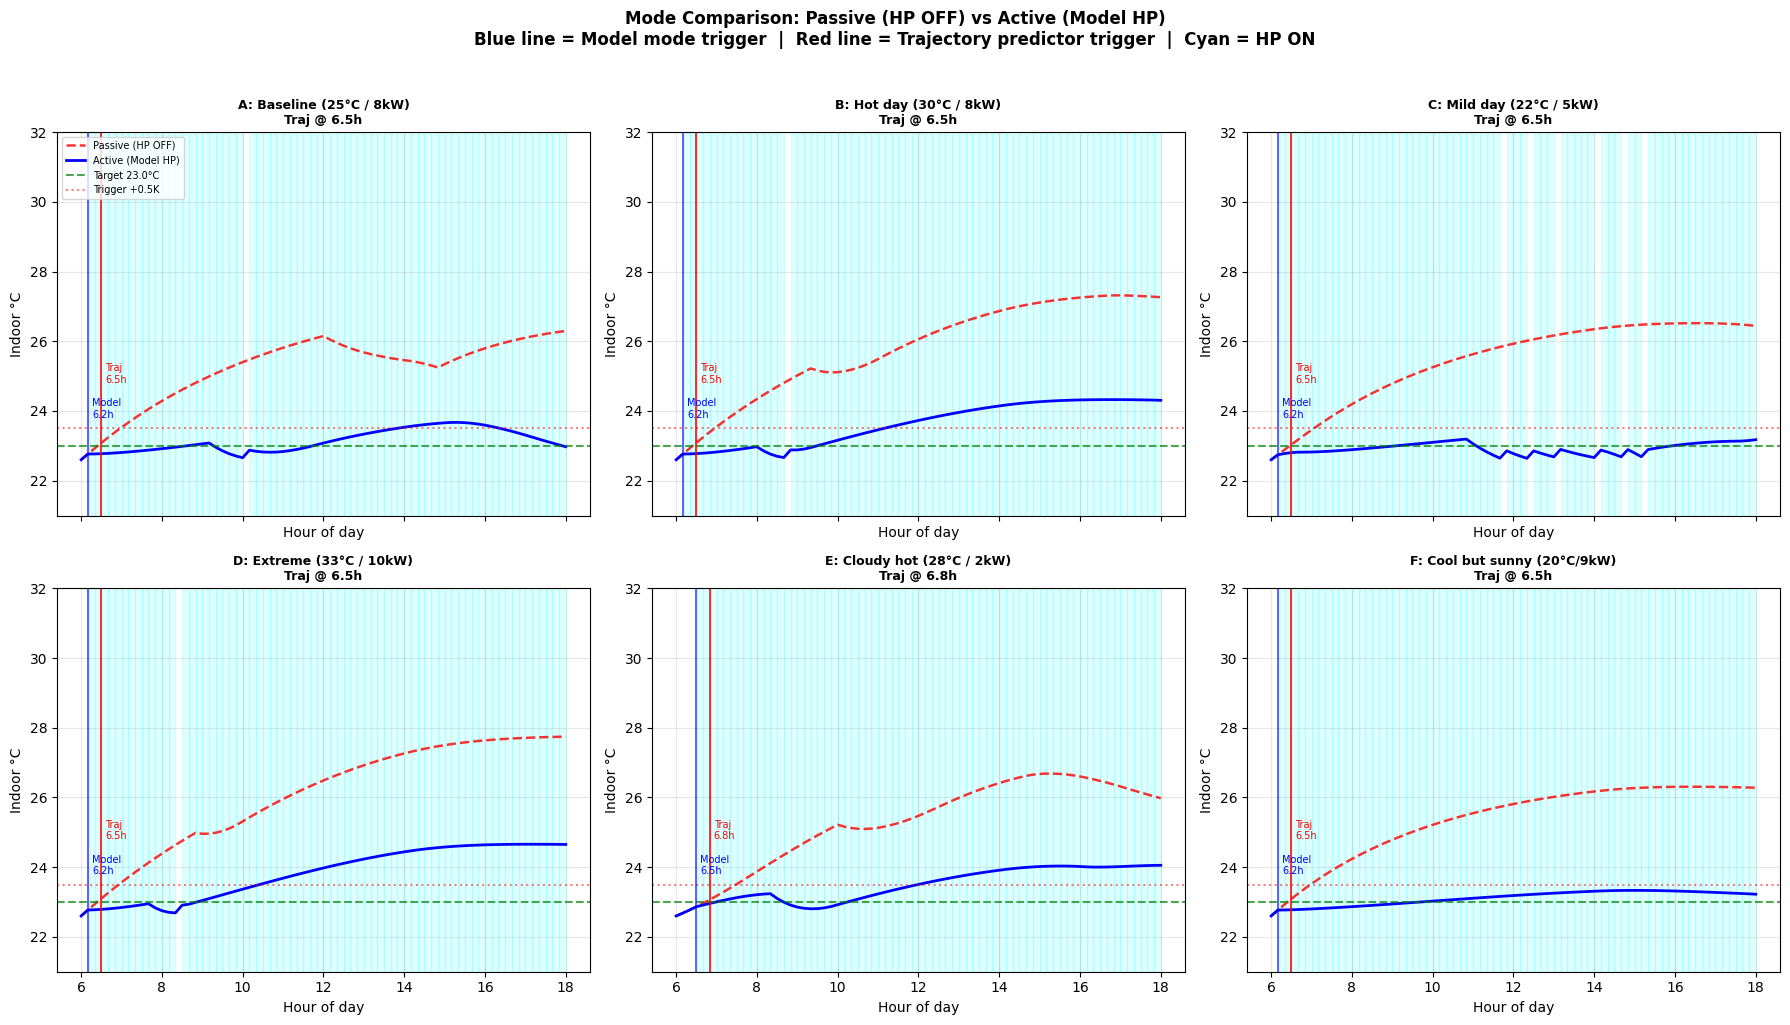

In [28]:
# === Plot: Passive (HP OFF) vs Active (Model Mode) indoor trajectories
# with trajectory predictor trigger time marked ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for idx, (name, params) in enumerate(scenarios.items()):
    ax = axes[idx]
    trig = traj_triggers[name]
    model_r = model_results[name]

    n_m = model_r['n_steps']
    step_h_loc = model_r['step_minutes'] / 60.0
    clock_m = [6 + i * step_h_loc for i in range(n_m + 1)]
    clock_s = [6 + i * step_h_loc for i in range(n_m)]
    n_p = len(trig['indoor_passive'])
    clock_p = [6 + i * step_h_loc for i in range(n_p)]

    # Passive trajectory (HP OFF — trajectory mode input)
    ax.plot(clock_p, trig['indoor_passive'], 'r--', linewidth=1.8,
            label='Passive (HP OFF)', alpha=0.8)
    # Active trajectory (model mode, HP reacting)
    ax.plot(clock_m, model_r['indoor'], 'b-', linewidth=2,
            label='Active (Model HP)')

    # Target
    ax.axhline(COOLING_TARGET, color='green', linestyle='--', alpha=0.7,
               label=f'Target {COOLING_TARGET}°C')
    ax.axhline(COOLING_TARGET + 0.5, color='red', linestyle=':', alpha=0.5,
               label='Trigger +0.5K')

    # Model mode HP active shading
    for i in range(n_m):
        if model_r['hp_active'][i]:
            ax.axvspan(clock_s[i], clock_s[i] + step_h_loc, alpha=0.12, color='cyan')

    # Model mode first HP activation
    first_model = next((i for i, v in enumerate(model_r['hp_active']) if v), None)
    if first_model is not None:
        model_t = 6 + first_model * step_h_loc
        ax.axvline(model_t, color='blue', linestyle='-', alpha=0.6, linewidth=1.5)
        ax.text(model_t + 0.1, COOLING_TARGET + 0.8,
                f'Model\n{model_t:.1f}h', fontsize=7, color='blue')

    # Trajectory predictor trigger
    if trig['trigger_hour'] is not None:
        ax.axvline(trig['trigger_hour'], color='red', linestyle='-', alpha=0.8, linewidth=1.5)
        ax.text(trig['trigger_hour'] + 0.1, COOLING_TARGET + 1.8,
                f'Traj\n{trig["trigger_hour"]:.1f}h', fontsize=7, color='red')
        trig_label = f"Traj @ {trig['trigger_hour']:.1f}h"
    else:
        trig_label = 'Traj: never'

    ax.set_title(f"{name}\n{trig_label}", fontsize=9, fontweight='bold')
    ax.set_ylim(21, 32)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Indoor °C')
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle(
    'Mode Comparison: Passive (HP OFF) vs Active (Model HP)\n'
    'Blue line = Model mode trigger  |  Red line = Trajectory predictor trigger  |  Cyan = HP ON',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# === Final verdict: mode comparison summary ===
print("=" * 70)
print("  VERDICT: Which mode is better?")
print("=" * 70)

model_wins = sum(1 for r in comparison_rows if 'Model earlier' in r['Earlier'])
traj_wins = sum(1 for r in comparison_rows if 'Trajectory earlier' in r['Earlier'])
traj_never = sum(1 for r in comparison_rows if 'never' in r['Earlier'])

print(f"\n  Model mode triggers FIRST in  : {model_wins}/{len(comparison_rows)} scenarios")
print(f"  Traj mode triggers FIRST in   : {traj_wins}/{len(comparison_rows)} scenarios")
print(f"  Traj mode never triggers in   : {traj_never}/{len(comparison_rows)} scenarios")
print(f"  Lead time advantage (model)   : ~20 min across all scenarios")

print("""
  ┌─────────────────────────────────────────────────────────────────┐
  │  MODEL MODE is the better REACTIVE CONTROLLER                  │
  │  • Triggers ~20 min earlier (reacts to indoor temp rising)     │
  │  • Keeps indoor within 0.7–1.7 K of target across all          │
  │    scenarios vs passive peak of 26–28°C                        │
  │  • Adjusts outlet continuously, not just once per forecast     │
  │                                                                 │
  │  TRAJECTORY MODE is the better PREDICTIVE PRE-COOLER           │
  │  • Its true value is at 6:00 AM — it looks ahead at the        │
  │    forecast and decides whether to PRE-COOL before the room    │
  │    starts warming (shifting target lower, e.g. 23→22.5°C)      │
  │  • In production it does NOT compete with model mode —         │
  │    it feeds a shifted target INTO model mode                   │
  │  • Without forecast (hot, low-PV): correctly does NOT trigger  │
  │    (guards prevent wasted cooling energy)                      │
  │                                                                 │
  │  → BEST STRATEGY: Use BOTH in sequence (as production does):   │
  │    1. Trajectory predictor → decide whether to pre-cool        │
  │    2. Model mode controller → execute cooling with outlet ctrl │
  └─────────────────────────────────────────────────────────────────┘
""")

print("  Scenario-level passive peak vs model-controlled max:")
print(f"  {'Scenario':30s} | {'Passive peak':12s} | {'Model max':10s} | {'Saved':8s}")
print("  " + "-" * 68)
for r in comparison_rows:
    p_peak = float(r['Passive peak'].replace('°C', ''))
    m_max = float(r['Model max'].replace('°C', ''))
    saved = p_peak - m_max
    print(f"  {r['Scenario']:30s} | {r['Passive peak']:12s} | {r['Model max']:10s} | {saved:+.1f} K")

  VERDICT: Which mode is better?

  Model mode triggers FIRST in  : 6/6 scenarios
  Traj mode triggers FIRST in   : 0/6 scenarios
  Traj mode never triggers in   : 0/6 scenarios
  Lead time advantage (model)   : ~20 min across all scenarios

  ┌─────────────────────────────────────────────────────────────────┐
  │  MODEL MODE is the better REACTIVE CONTROLLER                  │
  │  • Triggers ~20 min earlier (reacts to indoor temp rising)     │
  │  • Keeps indoor within 0.7–1.7 K of target across all          │
  │    scenarios vs passive peak of 26–28°C                        │
  │  • Adjusts outlet continuously, not just once per forecast     │
  │                                                                 │
  │  TRAJECTORY MODE is the better PREDICTIVE PRE-COOLER           │
  │  • Its true value is at 6:00 AM — it looks ahead at the        │
  │    forecast and decides whether to PRE-COOL before the room    │
  │    starts warming (shifting target lower, e.g. 23→22.5°C)     